In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import plotly.express as px

In [2]:
df = pd.read_csv(
    "../data/processed/ev_sales_feature_engineered.csv",
    parse_dates=["Date"]
)

df.head()

,Date,Year,Month,State,Vehicle_Category,EV_Sales,Quarter,Month_Name,Year_Month,Lag_1,Lag_2,Lag_3,Rolling_3,Rolling_STD_3,MoM_Growth
0,2021-01-01,2021,1,Delhi,Electric 2W,2300,1,January,2021-01,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,2021-02-01,2021,2,Delhi,Electric 2W,2450,1,February,2021-02,2300.0,0.0,0.0,0.000000,0.000000,6.521739
2,2021-03-01,2021,3,Delhi,Electric 2W,2860,1,March,2021-03,2450.0,2300.0,0.0,2536.666667,289.885035,16.734694
3,2021-04-01,2021,4,Delhi,Electric 2W,2700,2,April,2021-04,2860.0,2450.0,2300.0,2670.000000,206.639783,-5.594406
4,2021-05-01,2021,5,Delhi,Electric 2W,3020,2,May,2021-05,2700.0,2860.0,2450.0,2860.000000,160.000000,11.851852


In [3]:
df = pd.get_dummies(
    df,
    columns=["State", "Vehicle_Category"],
    drop_first=True,
    dtype=int
)

In [4]:
y = df["EV_Sales"]

In [5]:
X = df.drop(
    columns=[
        "Date",
        "EV_Sales",
        "Month_Name",
        "Year_Month"
    ]
)


In [6]:
print(X)

     Year  Month  Quarter   Lag_1   Lag_2   Lag_3    Rolling_3  Rolling_STD_3  \
0    2021      1        1     0.0     0.0     0.0     0.000000       0.000000   
1    2021      2        1  2300.0     0.0     0.0     0.000000       0.000000   
2    2021      3        1  2450.0  2300.0     0.0  2536.666667     289.885035   
3    2021      4        2  2860.0  2450.0  2300.0  2670.000000     206.639783   
4    2021      5        2  2700.0  2860.0  2450.0  2860.000000     160.000000   
..    ...    ...      ...     ...     ...     ...          ...            ...   
283  2022      8        3  1680.0  1550.0  1420.0  1690.000000     145.258390   
284  2022      9        3  1840.0  1680.0  1550.0  1846.666667     170.098011   
285  2022     10        4  2020.0  1840.0  1680.0  2053.333333     231.804515   
286  2022     11        4  2300.0  2020.0  1840.0  2280.000000     250.599282   
287  2022     12        4  2520.0  2300.0  2020.0  2506.666667     200.333056   

     MoM_Growth  State_Karn

In [7]:
print(X.shape)
print(y.shape)

(288, 14)
(288,)


In [8]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
print(X_train.dtypes)

Year                              int64
Month                             int64
Quarter                           int64
Lag_1                           float64
Lag_2                           float64
Lag_3                           float64
Rolling_3                       float64
Rolling_STD_3                   float64
MoM_Growth                      float64
State_Karnataka                   int64
State_Maharashtra                 int64
State_Uttar Pradesh               int64
Vehicle_Category_Electric 3W      int64
Vehicle_Category_Electric 4W      int64
dtype: object


In [11]:
print(X.columns)

Index(['Year', 'Month', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_3',
       'Rolling_STD_3', 'MoM_Growth', 'State_Karnataka', 'State_Maharashtra',
       'State_Uttar Pradesh', 'Vehicle_Category_Electric 3W',
       'Vehicle_Category_Electric 4W'],
      dtype='object')


In [12]:
y_pred = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(y_test, y_pred)

In [14]:
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.4f}")

MAE  : 306.16
MSE  : 210733.86
RMSE : 459.06
R²   : 0.9750
MAPE : 0.1137


In [15]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
230,6100,6236.652245
231,5850,6357.439717
232,6400,6177.051541
233,6900,6926.216948
234,7350,7380.674997


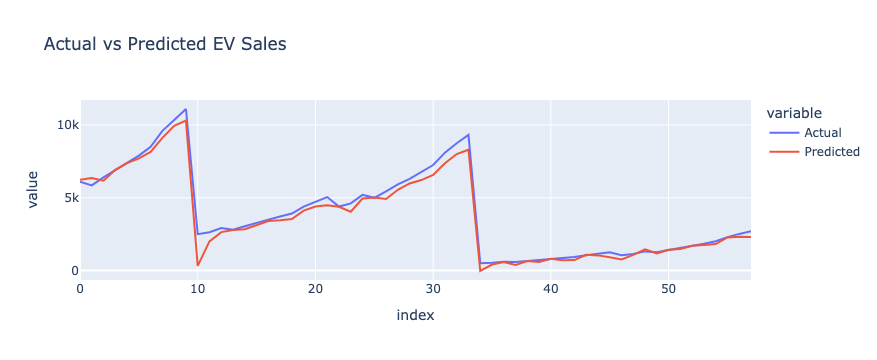

In [16]:
fig = px.line(
    results.reset_index(drop=True),
    y=["Actual", "Predicted"],
    title="Actual vs Predicted EV Sales"
)

fig.show()

In [17]:
results["Residual"] = (
    results["Actual"] - results["Predicted"]
)

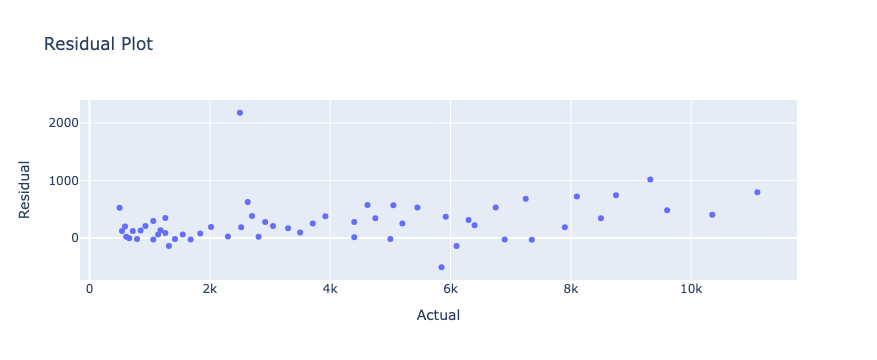

In [18]:
fig = px.scatter(
    results,
    x="Actual",
    y="Residual",
    title="Residual Plot"
)

fig.show()

In [19]:
joblib.dump(
    model,
    "../models/linear_regression.pkl"
)

['../models/linear_regression.pkl']

## Observations

- Linear Regression is used as the baseline model.
- It captures the overall trend in EV sales.
- Some peaks are under-predicted because the model assumes a linear relationship.
- More complex models will be compared against this baseline.

In [20]:
import joblib

joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

['../models/feature_columns.pkl']